In [1]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt

In [ ]:
# with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_allMovies_resample.pkl', 'rb') as f:
#     scores_dict = pickle.load(f)
# with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\times_allMovies_resample.pkl', 'rb') as f:
#     time_dict= pickle.load(f)

# print(len(scores_dict.keys()))
# print(len(time_dict.keys()))

102
102


In [2]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_allMovies_resample_nosmooth_new.pkl', 'rb') as f:
    scores_dict = pickle.load(f)
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\times_allMovies_resample_nosmooth_new.pkl', 'rb') as f:
    time_dict = pickle.load(f)

print(len(scores_dict.keys()))
print(len(time_dict.keys()))

102
102


In [3]:
print(list(scores_dict.keys())[91])

5 Centimeters Per Second


### Dynamic indices

In [4]:
# Autocorrelation
def exp_decay(x, A, lambda_):
    return A * np.exp(-lambda_ * x)

def power_law(x, A, alpha):
    return A * x**(-alpha)

def r_squared(y, y_fit):
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

# auto-correlation
# from scipy.signal import correlate
from scipy.optimize import curve_fit
from scipy import stats

colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
keys = list(scores_dict.keys())
print(len(keys))

r2_exp_all = np.zeros((len(keys),6))
r2_power_all = np.zeros((len(keys),6))
lambda_movies = np.zeros((len(keys), 6))
A_exp_movies = np.zeros((len(keys), 6))
for i in range(len(keys)):
    # plt.figure(figsize=(13,5))
    # print(scores_dict[keys[i]].shape)
    scores_norm = (scores_dict[keys[i]] - np.mean(scores_dict[keys[i]], axis=0, keepdims=True)) / np.std(scores_dict[keys[i]], axis=0, keepdims=True)
    for j in range(6):
        auto_corr = np.correlate(scores_norm[:,j], scores_norm[:,j], mode='full')
        lags = np.arange(1, len(scores_norm[:,j]))
        popt, pcov = curve_fit(exp_decay, lags, auto_corr[len(scores_norm[:,j]):], p0=[1, 0.1], maxfev = 5000)  # 初始猜测 A=1, lambda=0.1
        A_fitted, lambda_fitted = popt
        lambda_movies[i, j] = lambda_fitted
        A_exp_movies[i, j] = A_fitted
        
        y_fit = exp_decay(lags, *popt)
        r2_exp = r_squared(auto_corr[len(scores_norm[:,j]):], y_fit)
        
        popt, pcov = curve_fit(power_law, lags, auto_corr[len(scores_norm[:,j]):], p0=[1, 1], maxfev = 5000)
        A_fitted, alpha_fitted = popt
        print(alpha_fitted)
        
        y_fit = power_law(lags, *popt)
        r2_power = r_squared(auto_corr[len(scores_norm[:,j]):], y_fit)
        print(r2_exp, r2_power)
        r2_exp_all[i,j] = r2_exp
        r2_power_all[i,j] = r2_power

102
0.7141001935595175
0.5136544745675455 0.41230414884289734
0.7446852058979738
0.4603747640745386 0.362261785770855
0.571007845681336
0.6501203130940432 0.3454452012139857
0.6029285037154368
0.5606670457214558 0.3546894989679482
0.6218951108734629
0.5541798643266387 0.3685179433609409
0.5908073041125372
0.6031742594821723 0.33598819933108326
0.6928179320122726
0.4417920178521557 0.40147568764346797
0.7135419229556561
0.4797493811913226 0.3597845741110265
0.5647954837434196
0.676787380730044 0.30107830347192444
0.6019184521518036
0.6462165682657676 0.34621895056098384
0.6022212153312754
0.669850519886337 0.3835048133313267
0.6029310880978404
0.5289113652378747 0.34518855656173675
0.7393542572453696
0.513760830955786 0.4354406754524598
0.7597385615918473
0.42502836856251025 0.3364570316373422
0.6728204446015612
0.5531079428440142 0.41807388665795286
0.6180926934732228
0.525653563563993 0.3063740173363114
0.639576230069368
0.47748836235745606 0.3501651911321292
0.7124505317664341
0.4813

C:\Users\Windows\AppData\Local\Temp\ipykernel_13028\2890399746.py:3: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-lambda_ * x)
C:\Users\Windows\AppData\Local\Temp\ipykernel_13028\2890399746.py:3: RuntimeWarning: overflow encountered in multiply
  return A * np.exp(-lambda_ * x)
C:\Users\Windows\AppData\Local\Temp\ipykernel_13028\2890399746.py:6: RuntimeWarning: overflow encountered in power
  return A * x**(-alpha)
C:\Users\Windows\AppData\Local\Temp\ipykernel_13028\2890399746.py:6: RuntimeWarning: overflow encountered in multiply
  return A * x**(-alpha)


0.7654093988786075
0.3822665903802652 0.3538495447539797
0.6760775976833308
0.591237716167262 0.3453720942465266
0.6500820731300898
0.5524986266060771 0.30058163575856356
0.6637988721128142
0.5578962913719221 0.3224038992202095
0.7255792606427215
0.4286929545791539 0.331367448927526
0.6782361163115289
0.43369410487603943 0.3301765881819302
0.8245624882707038
0.43585876796361633 0.34226717507947446
0.6457255497017776
0.43811496588372323 0.3909231744902133
0.6495605105879788
0.4059171287878097 0.26550647401015237
0.6584268544107076
0.4892929752347994 0.3374794272165459
0.6568275028720726
0.4675163292019042 0.3675281532800754
0.6200723695200163
0.584429534647676 0.35518154799455026
0.642564182617904
0.6335029534190506 0.470687125636449
0.6183765393393373
0.5329616983562776 0.3867363891915192
0.6565664159302064
0.39876760597544714 0.21176298809143612
0.6618363568805575
0.4777599624354446 0.274777064503272
0.64693951992378
0.49932124707527725 0.2782186442034731
0.700312332782355
0.506195382

Batman Dark Knight


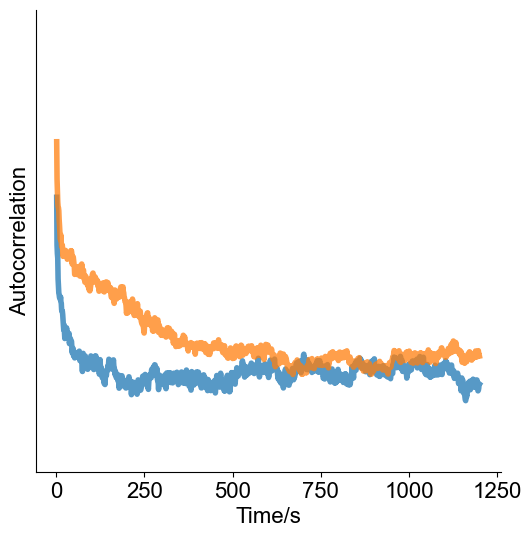

In [5]:
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'Arial'
for i in range(1):
    plt.figure(figsize=(6,6))
    print(keys[i])
    scores_norm = (scores_dict[keys[i]] - np.mean(scores_dict[keys[i]], axis=0, keepdims=True)) / np.std(scores_dict[keys[i]], axis=0, keepdims=True)
    for j in [1,2]:
        auto_corr = np.correlate(scores_norm[:,j], scores_norm[:,j], mode='full')
        lags = np.arange(1, len(scores_norm[:,j]))
        # fitted = A_exp_movies[i,j] * np.exp(-lambda_movies[i,j] * lags)
        plt.plot(lags[:1200], auto_corr[len(scores_norm[:,j]):len(scores_norm[:,j])+1200], color=colors[j], alpha=0.75, linewidth=4)
        # plt.plot(lags[:1200], fitted[:1200], '--')
    plt.xlabel('Time/s')
    plt.yticks([])
    plt.ylabel('Autocorrelation')
    plt.ylim([-1200,4500])
    # plt.legend(['Surprise - original', 'Surprise - fitted', 'Sadness - original', 'Sadness - fitted'])
    # plt.savefig('figures/autocorr_surprise_sadness_example.jpg')
    ax = plt.gca()
    ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)

    plt.show()

In [6]:
# Hurst component (self-similarity)
from hurst import compute_Hc, random_walk
Hurst_all = np.zeros((len(keys),6))
for i in range(len(keys)):
    for j in range(6):
        H, c, data = compute_Hc(scores_dict[keys[i]][:,j]+1., kind='price', simplified=True)
        Hurst_all[i,j] = H
print(np.mean(Hurst_all, axis=0), np.std(Hurst_all, axis=0))

[0.34457704 0.33294698 0.22298084 0.23918229 0.26509087 0.23348581] [0.0505192  0.05685779 0.03285486 0.04158036 0.0400322  0.03533973]


In [7]:
# Controllability
from scipy.linalg import inv, norm
from scipy.optimize import minimize_scalar
import mou_model as pm

def system_identification(time_series):
    
    mou = pm.MOU()
    mou.fit(time_series, lag = 1)
    Jacobian = np.copy(mou.J)
    Sigma = np.copy(mou.Sigma)
    
    print(' - model fit of empirical covariances: ', end = '')
    print(mou.d_fit['correlation'])
    
    return Jacobian, Sigma

def average_controllability(Jacobian, Sigma):

    integral = -inv(Jacobian + Jacobian.T)
    AC = np.sqrt(np.diag(np.dot(np.dot(Sigma.T, integral), Sigma)))
    
    return AC

def modal_controllability(Jacobian, Sigma):

    n = Jacobian.shape[0]
    MC = np.array([-1/minimize_scalar(lambda omega: -norm(Sigma[i,i]*inv(1j*omega*np.eye(n)-Jacobian)[:,i], 2)).fun for i in range(n)])

    return MC

keys = list(scores_dict.keys())
MC_all = np.zeros((len(keys), 6))
AC_all = np.zeros((len(keys), 6))
for i in range(len(keys)):
    Jacobian, Sigma = system_identification(scores_dict[keys[i]])
    AC = average_controllability(Jacobian, Sigma)
    MC = modal_controllability(Jacobian, Sigma)
    AC_all[i] = AC
    MC_all[i] = MC

 - model fit of empirical covariances: 0.8640438705035453
 - model fit of empirical covariances: 0.8785252534285667
 - model fit of empirical covariances: 0.9203367510174076
 - model fit of empirical covariances: 0.9075976034796396
 - model fit of empirical covariances: 0.8621280680832071
 - model fit of empirical covariances: 0.9283465025650043
 - model fit of empirical covariances: 0.9063124926658013
 - model fit of empirical covariances: 0.8983542536936184
 - model fit of empirical covariances: 0.8584838522905027
 - model fit of empirical covariances: 0.873207921123552
 - model fit of empirical covariances: 0.8747873302476777
 - model fit of empirical covariances: 0.8677216661876712
 - model fit of empirical covariances: 0.9171391057030089
 - model fit of empirical covariances: 0.9257629550772944
 - model fit of empirical covariances: 0.922498912481015
 - model fit of empirical covariances: 0.933309441179086
 - model fit of empirical covariances: 0.9155502743173853
 - model fit of e

In [10]:
print(np.nanmean(AC_all, axis=0), np.nanstd(AC_all, axis=0))
print(np.mean(MC_all, axis=0), np.std(MC_all, axis=0))

[1.60827008 1.00201256 1.73078726 1.2477638  0.68365557 0.77535327] [0.33312744 0.21645224 0.71361503 0.30245091 0.19799517 0.3197825 ]
[0.24460945 0.43256626 0.28536484 0.33227247 0.64713758 0.62360764] [0.05675328 0.07020222 0.13527374 0.09332372 0.20707397 0.29056748]


In [11]:
# Instability
instability_all = np.zeros((len(scores_dict.keys()), 6))
count = 0
for key in scores_dict.keys():
    instability_all[count,:] = np.mean(np.square(scores_dict[key][1:,:] - scores_dict[key][:-1,:]), axis=0)
    count += 1

In [ ]:
# np.save('results/MC_all.npy', MC_all)
# np.save('results/AC_all.npy', AC_all)
# np.save('results/instability_all.npy', instability_all)
# np.save('results/lambda_movies.npy', lambda_movies)
# np.save('results/Hurst_all.npy', Hurst_all)

In [12]:
indices_name = ['inertia', 'instability', 'self_similarity', 'AC', 'MC']

(102, 6)


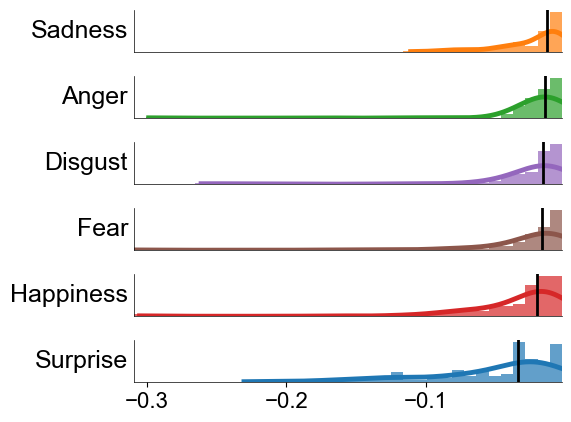

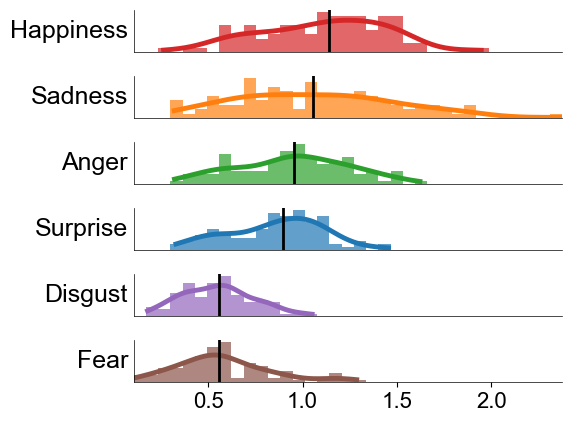

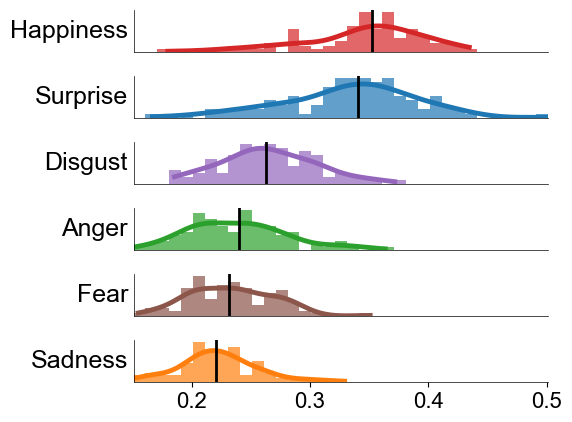

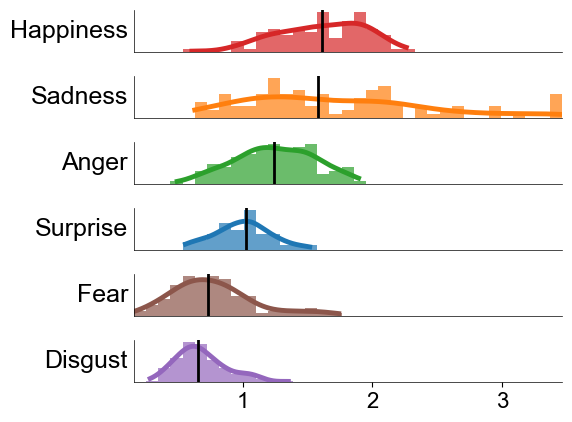

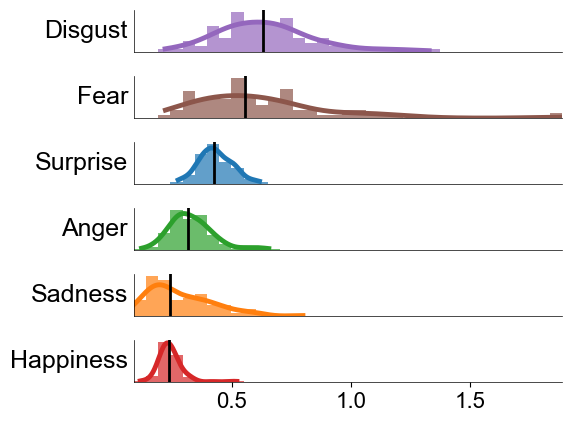

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16

colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
features = [-lambda_movies, instability_all, Hurst_all, AC_all, MC_all]
xlims = [[np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan]]
print(features[0].shape)
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"] 
# emos = ['Ha', 'Su', 'Sa', 'An', 'Di', 'Fe']
for j in range(5):
    plt.figure(figsize=(6,4.5))

    median = [np.nanmedian(features[j][:, i]) for i in range(6)]
    sorted_indices = np.argsort(median)[::-1]  

    all_data = np.concatenate([features[j][:, i] for i in range(6)], axis=0) 
    bin_edges = np.histogram(all_data[~np.isnan(all_data)], bins=35)[1]  
    
    for i, idx in enumerate(sorted_indices):  
        plt.subplot(6,1,i+1)

        plt.hist(features[j][:, idx], bins=bin_edges, color=colors[idx], alpha=0.7, density=True)

        kde = gaussian_kde(features[j][:, idx][~np.isnan(features[j][:, idx])])
        x = np.linspace(np.nanmin(features[j][:, idx]), np.nanmax(features[j][:, idx]), 1000)
        plt.plot(x, kde(x), color=colors[idx], linestyle='-', linewidth=3.5)

        median_val = np.nanmedian(features[j][:, idx])
        plt.axvline(median_val, color='black', linewidth=2, linestyle='-')

        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['bottom'].set_linewidth(0.5)
        plt.gca().spines['left'].set_linewidth(0.5)
        
        if i < 5: 
            plt.xticks([])
        plt.yticks([])

        if np.isnan(xlims[j][0]):
            plt.xlim([np.nanmin(features[j]), np.nanmax(features[j])])
        else:
            plt.xlim([xlims[j][0], xlims[j][1]])

        plt.ylabel(emos[idx], rotation=0, ha='right', va='center', fontsize=18)

    plt.tight_layout()
    plt.savefig('figures/%s_nosmooth.svg' % indices_name[j])
    plt.show()
